# Fake News Detection with RNNs and LSTMs
**Course:** Deep Learning — IE University · **Architecture family:** Recurrent Neural Networks (SimpleRNN / LSTM / BiLSTM)

This notebook is the analytical backend of the MVP. It takes the raw text of a news article or headline
and predicts whether it is **fake** or **real**.

How the notebook is organised:

| Part | What it covers |
|---|---|
| Section 1 | Business framing |
| Sections 2–7 | Data loading & cleaning, preprocessing, and the input pipeline |
| Sections 8–10 | The three architectures, evaluation, and error analysis |
| Section 11 | End-to-end model export for the frontend |

> **Label convention used everywhere in this notebook:** `1 = FAKE`, `0 = REAL`.
> The positive class is "fake" because detecting fake news is the job to be done.

## 1. Business framing

**The problem.** Newsrooms, social platforms, and content-moderation teams receive far more articles per
day than humans can fact-check. Misinformation that slips through erodes public trust, and over-blocking
legitimate reporting damages credibility and reach. A model that flags *likely* fake articles for human
review turns an impossible manual task into a manageable triage queue.

**Value proposition.** The model is a **triage assistant**, not an oracle:
- **Saves time** — reviewers see a ranked queue instead of an undifferentiated feed.
- **Reduces cost** — a small moderation team can cover a much larger volume of content.
- **Protects revenue & trust** — fewer misinformation incidents reaching readers, fewer brand-safety problems.

**Cost of the two error types (this framing drives our metric choice):**

| Error | Meaning | Business cost |
|---|---|---|
| **False Negative** (fake → predicted real) | Misinformation reaches readers | Trust damage, brand-safety incidents, regulatory risk |
| **False Positive** (real → predicted fake) | Legitimate article flagged | Wasted reviewer time, risk of over-censoring real reporting |

Because the costlier mistake is usually the **false negative**, we report **recall on the fake class** and
**ROC-AUC** alongside accuracy, rather than relying on accuracy alone.


## 2. Setup & configuration

All configuration for the notebook lives in the cell below. `DATA_PATH` points at the labelled CSV; if that
file is absent, a synthetic dataset is generated so every cell still runs end-to-end.

In [1]:
import os
import re
import string
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import (
    Input, Embedding, SimpleRNN, LSTM, Bidirectional, Dense, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# ---- Reproducibility ----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---- Smoke-test switch -------------------------------------------------------
# When FAKE_NEWS_SMOKE_TEST=1 the data and number of epochs are shrunk so the whole
# notebook runs in seconds. Unset it for a full run with the defaults below.
SMOKE_TEST = os.environ.get("FAKE_NEWS_SMOKE_TEST", "0") == "1"

# ---- Project configuration ---------------------------------------------------
# Point this at the raw labelled CSV (Kaggle's train.csv: id, title, author, text, label).
# All data cleaning — column selection, dropping empties/duplicates, label
# normalisation — happens in this notebook (Section 3), not in any external script.
DATA_PATH        = "../data/raw/fake_train.csv"
TEXT_COLUMN      = "text"   # use the article body; cleaning happens in this notebook (Section 3)
LABEL_COLUMN     = None     # e.g. "label" -> leave None to auto-detect
FAKE_LABEL_VALUE = None     # value in the label column that means "fake" -> None = auto

# Text / model hyperparameters
VOCAB_SIZE       = 10000    # keep the 10k most frequent tokens
SEQUENCE_LENGTH  = 250      # pad / truncate every article to 250 tokens
EMBEDDING_DIM    = 64       # learned word-vector size
BATCH_SIZE       = 64
EPOCHS           = 2 if SMOKE_TEST else 6
N_SYNTHETIC      = 800 if SMOKE_TEST else 5000   # only used by the fallback dataset

MODELS_DIR  = "../models"
FIGURES_DIR = "../reports/figures"
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print("TensorFlow version :", tf.__version__)
print("Smoke-test mode    :", SMOKE_TEST)
print("Epochs             :", EPOCHS)

TensorFlow version : 2.21.0
Smoke-test mode    : False
Epochs             : 6


## 3. Load the data

`load_dataset()`:
1. Reads the CSV at `DATA_PATH` and auto-detects the text and label columns.
2. Cleans the data — strips whitespace, drops blank and duplicate articles, and normalises the labels to
   `1 = fake`, `0 = real` (handling `0/1`, `fake/real`, `true/false`, and similar encodings).
3. Falls back to a synthetic dataset when `DATA_PATH` is absent, so the notebook always runs.

In [2]:
def build_synthetic_fake_news(n=5000, seed=SEED):
    """A small, learnable stand-in dataset. Real news = measured/sourced language;
    fake news = sensational clickbait. Lets every cell run before the real data arrives.
    Enough variety (sources, places, topics, closing line, year) that de-duplication
    keeps the two classes balanced."""
    rng = random.Random(seed)
    topics = ["the economy", "a new health study", "the election", "a tech company",
              "climate policy", "the stock market", "a vaccine", "local government",
              "international trade", "artificial intelligence", "education reform", "the housing market"]
    sources = ["Reuters", "the Associated Press", "government officials", "researchers",
               "the city council", "a peer-reviewed study", "the central bank", "health authorities"]
    places = ["Washington", "Brussels", "Tokyo", "London", "the capital", "New York", "Geneva", "the region"]

    real_templates = [
        "According to {src}, officials in {place} announced new measures on {topic} on Tuesday",
        "A report published by {src} found moderate changes related to {topic}, analysts said",
        "{src} confirmed that recent data on {topic} in {place} was consistent with earlier estimates",
        "Authorities in {place} said the situation around {topic} remained stable, citing {src}",
        "Experts cited by {src} explained that {topic} is expected to develop gradually this year",
        "The committee reviewed evidence on {topic} and, according to {src}, recommended further study",
    ]
    real_extra = [
        "The findings were described as preliminary but encouraging",
        "Officials added that no immediate action was required",
        "Analysts noted the figures matched seasonal expectations",
        "The statement was released alongside supporting documentation",
        "Independent reviewers are expected to verify the results",
        "Further updates were promised in the coming weeks",
        "The data was collected over a twelve month period",
        "Spokespeople declined to speculate beyond the published numbers",
    ]
    fake_templates = [
        "SHOCKING {place} officials are HIDING the TRUTH about {topic} you WONT believe what happens next",
        "BREAKING secret documents PROVE that {topic} is a total HOAX and the media will NEVER tell you",
        "They dont want you to know this ONE WEIRD trick about {topic} that experts absolutely HATE",
        "EXPOSED the REAL reason behind {topic} will leave you SPEECHLESS",
        "WAKE UP {place} is being CONTROLLED and {topic} is just the beginning of their EVIL plan",
        "100 percent CONFIRMED insiders reveal {topic} is FAKE and everyone is being LIED to right now",
    ]
    fake_extra = [
        "Share this before they DELETE it forever",
        "The mainstream media is TERRIFIED of this",
        "Doctors and scientists are FURIOUS about the truth",
        "Only the brave will dare to read until the very end",
        "This is the story THEY tried to bury",
        "Wake up before it is too LATE for all of us",
        "Forward this to everyone you know right NOW",
        "The elites do NOT want this getting out",
    ]

    rows = []
    half = n // 2
    for _ in range(half):
        base = rng.choice(real_templates).format(
            src=rng.choice(sources), place=rng.choice(places), topic=rng.choice(topics))
        rows.append((f"{base} in {rng.randint(2019, 2025)}. {rng.choice(real_extra)}.", 0))
    for _ in range(n - half):
        base = rng.choice(fake_templates).format(place=rng.choice(places), topic=rng.choice(topics))
        rows.append((f"{base} {rng.choice(fake_extra)} {rng.randint(2019, 2025)}", 1))
    rng.shuffle(rows)
    return pd.DataFrame(rows, columns=["text", "label"])


def _autodetect_columns(frame):
    text_like  = ["text", "content", "article", "body", "news", "headline", "title"]
    label_like = ["label", "target", "class", "y", "is_fake", "fake", "category"]
    text_col  = TEXT_COLUMN  or next((c for c in frame.columns if c.lower() in text_like), None)
    label_col = LABEL_COLUMN or next((c for c in frame.columns if c.lower() in label_like), None)
    if text_col is None:  # fall back to the longest free-text column
        obj_cols = [c for c in frame.columns if frame[c].dtype == object]
        text_col = max(obj_cols, key=lambda c: frame[c].astype(str).str.len().mean()) if obj_cols else None
    if label_col is None:  # fall back to a binary column
        label_col = next((c for c in frame.columns if frame[c].nunique(dropna=True) == 2), None)
    return text_col, label_col


def _map_labels_to_fake1(series):
    """Return a 0/1 series where 1 = fake, 0 = real."""
    if FAKE_LABEL_VALUE is not None:
        return (series == FAKE_LABEL_VALUE).astype(int)
    as_str = series.astype(str).str.strip().str.lower()
    fake_words = {"fake", "false", "1", "fake news", "unreliable", "junk", "fakenews"}
    real_words = {"real", "true", "0", "reliable", "legit", "trusted"}
    if (set(as_str.unique()) & fake_words) or (set(as_str.unique()) & real_words):
        return as_str.isin(fake_words).astype(int)
    if set(pd.unique(series)) <= {0, 1}:        # already numeric 0/1
        return series.astype(int)
    fake_val = series.value_counts().idxmin()   # assume the rarer class is "fake"
    print(f"  (could not infer label meaning; assuming minority value {fake_val!r} = fake)")
    return (series == fake_val).astype(int)


def load_dataset():
    if os.path.exists(DATA_PATH):
        print(f"Loading real dataset from: {DATA_PATH}")
        frame = pd.read_csv(DATA_PATH)
        text_col, label_col = _autodetect_columns(frame)
        print(f"  detected text column  = {text_col!r}")
        print(f"  detected label column = {label_col!r}")
        frame = frame[[text_col, label_col]].dropna()
        frame.columns = ["text", "label"]
        frame["label"] = _map_labels_to_fake1(frame["label"])
        frame["text"]  = frame["text"].astype(str)
        source = "real"
    else:
        print(f"DATA_PATH not found ({DATA_PATH}) -> building synthetic fallback dataset.")
        frame = build_synthetic_fake_news(N_SYNTHETIC)
        source = "synthetic"
    # Cleaning (all of it lives here, not in any external script): strip whitespace, then drop
    # articles that would tokenize to nothing. A row with no ASCII letter/digit becomes an empty
    # string once standardization (Section 6) removes punctuation and non-ASCII characters, and a
    # 0-token row breaks the batched tf.data pipeline. Finally drop exact duplicates.
    before = len(frame)
    frame["text"] = frame["text"].astype(str).str.strip()
    frame = frame[frame["text"].str.contains(r"[A-Za-z0-9]", regex=True, na=False)]
    frame = frame.drop_duplicates(subset="text").reset_index(drop=True)
    removed = before - len(frame)
    print(f"\nLoaded {len(frame):,} rows  |  source = {source}  |  cleaned out {removed:,} blank/duplicate rows")
    print(frame["label"].value_counts().rename({0: "real (0)", 1: "fake (1)"}))
    return frame, source


df, DATA_SOURCE = load_dataset()
df.head()

Loading real dataset from: ../data/raw/fake_train.csv
  detected text column  = 'text'
  detected label column = 'label'

Loaded 20,365 rows  |  source = real  |  cleaned out 396 blank/duplicate rows
label
real (0)    10387
fake (1)     9978
Name: count, dtype: int64


,text,label
0,House Dem Aide: We Didn’t Even See Comey’s Let...,1
1,Ever get the feeling your life circles the rou...,0
2,"Why the Truth Might Get You Fired October 29, ...",1
3,Videos 15 Civilians Killed In Single US Airstr...,1
4,Print \nAn Iranian woman has been sentenced to...,1


## 4. Exploratory data analysis

Two checks that matter for a text classifier: **class balance** (decides whether accuracy is trustworthy)
and **article length** (sanity-checks our `SEQUENCE_LENGTH = 250` truncation choice).

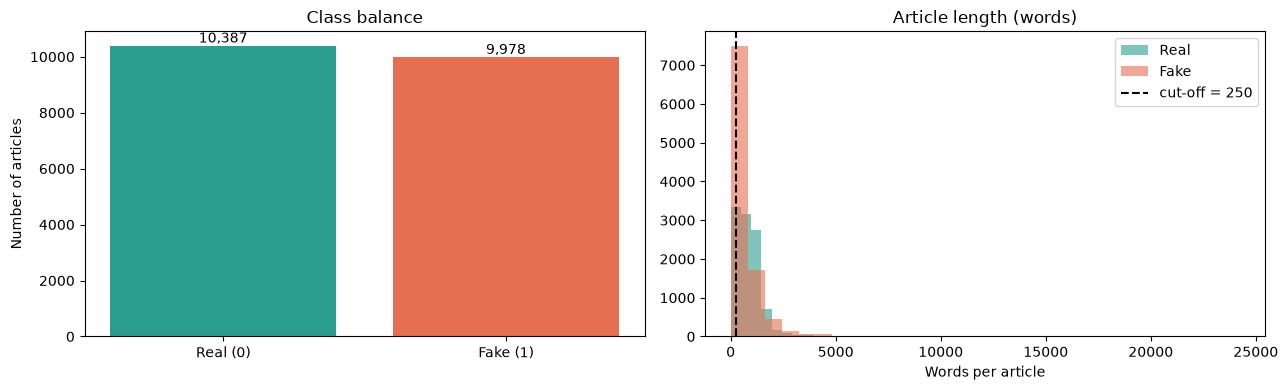

count    20365.0
mean       767.0
std        868.9
min          1.0
25%        277.0
50%        566.0
75%       1058.0
max      24234.0
Name: n_words, dtype: float64

Share of articles longer than 250 tokens (will be truncated): 77.8%


In [3]:
df["n_words"] = df["text"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = df["label"].value_counts().sort_index()
axes[0].bar(["Real (0)", "Fake (1)"], counts.values, color=["#2a9d8f", "#e76f51"])
axes[0].set_title("Class balance")
axes[0].set_ylabel("Number of articles")
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

axes[1].hist(df.loc[df.label == 0, "n_words"], bins=30, alpha=0.6, label="Real", color="#2a9d8f")
axes[1].hist(df.loc[df.label == 1, "n_words"], bins=30, alpha=0.6, label="Fake", color="#e76f51")
axes[1].axvline(SEQUENCE_LENGTH, color="black", linestyle="--", label=f"cut-off = {SEQUENCE_LENGTH}")
axes[1].set_title("Article length (words)")
axes[1].set_xlabel("Words per article")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "eda_overview.png"), dpi=120, bbox_inches="tight")
plt.show()

pct_truncated = (df["n_words"] > SEQUENCE_LENGTH).mean() * 100
print(df["n_words"].describe().round(1))
print(f"\nShare of articles longer than {SEQUENCE_LENGTH} tokens (will be truncated): {pct_truncated:.1f}%")

## 5. Stratified train / validation / test split — **70 / 15 / 15**

We split into three sets and **stratify on the label** so the fake/real ratio is preserved everywhere. The
test set is held out and only touched in Section 9 for the final, unbiased evaluation.

In [4]:
# .to_numpy() forces plain NumPy arrays. Some pandas builds store the text
# column as a pyarrow-backed array, which scikit-learn cannot index for the
# stratified split (raises "only integer scalar arrays can be converted ...").
X = df["text"].to_numpy(dtype=object)
y = df["label"].to_numpy()

# First carve off 30% for (val + test), then split that half-and-half -> 70/15/15
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

print(f"Train: {len(X_train):>6,}   fake ratio: {y_train.mean():.3f}")
print(f"Val:   {len(X_val):>6,}   fake ratio: {y_val.mean():.3f}")
print(f"Test:  {len(X_test):>6,}   fake ratio: {y_test.mean():.3f}")

Train: 14,255   fake ratio: 0.490
Val:    3,055   fake ratio: 0.490
Test:   3,055   fake ratio: 0.490


## 6. Text standardization & vectorization

The text preprocessing pipeline:

1. A custom `standardization` function: **lowercase → strip HTML tags → strip punctuation → drop non-ASCII
   characters**.
2. A `TextVectorization` layer that standardizes, tokenizes, maps tokens to integer IDs, and pads/truncates
   to `SEQUENCE_LENGTH`.
3. `adapt()` is called **on the training text only** — the vocabulary is never learned from val/test data,
   which would leak information.

The function is registered as a Keras serializable so the exported end-to-end model (Section 11) reloads
cleanly inside the Streamlit app.

In [5]:
@keras.utils.register_keras_serializable(package="fake_news")
def standardization(input_data):
    lowercase = tf.strings.lower(input_data)
    no_tag    = tf.strings.regex_replace(lowercase, "<[^>]+>", "")
    no_punct  = tf.strings.regex_replace(no_tag, "[%s]" % re.escape(string.punctuation), "")
    # Drop non-ASCII characters (curly quotes, accents, stray bytes from the source CSV).
    # This keeps the learned vocabulary ASCII-only so the exported .keras reloads on any
    # platform regardless of the default file encoding — Windows' cp1252 otherwise raises
    # a 'charmap' codec error when reading a vocabulary that contains non-ASCII bytes.
    ascii_only = tf.strings.regex_replace(no_punct, r"[^\x00-\x7f]+", "")
    # Collapse any whitespace runs left behind into single spaces.
    return tf.strings.regex_replace(ascii_only, r"\s+", " ")


vectorize_layer = layers.TextVectorization(
    standardize=standardization,
    max_tokens=VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=SEQUENCE_LENGTH,
)

# Learn the vocabulary from TRAINING TEXT ONLY (no leakage)
vectorize_layer.adapt(X_train)

vocab = vectorize_layer.get_vocabulary()
print("Vocabulary size:", len(vocab))
print("First 12 tokens (index 0='', 1='[UNK]'):", [str(t) for t in vocab[:12]])

Vocabulary size: 10000
First 12 tokens (index 0='', 1='[UNK]'): ['', '[UNK]', 'the', 'to', 'of', 'and', 'a', 'in', 'that', 'is', 'for', 'on']


## 7. Build the `tf.data` input pipeline

Each split becomes a batched, prefetched dataset of `(integer_sequence, label)` pairs. Only the training set
is shuffled.

In [6]:
def make_dataset(texts, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((texts, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(texts), seed=SEED)
    ds = ds.map(lambda x, y: (vectorize_layer(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


train_dataset = make_dataset(X_train, y_train, shuffle=True)
val_dataset   = make_dataset(X_val,   y_val)
test_dataset  = make_dataset(X_test,  y_test)

# Peek at one batch to confirm shapes: (batch, 250) ints and (batch,) labels
for xb, yb in train_dataset.take(1):
    print("Batch X shape:", xb.shape, "| Batch y shape:", yb.shape)
    print("Example token IDs:", xb[0][:15].numpy())

Batch X shape: (64, 250) | Batch y shape: (64,)
Example token IDs: [   6  224   33 2055 2071    2 1522  850    3    1   29  620  455    7
    3]


## 8. The three architectures

Three recurrent models of increasing capacity. All share the same `Embedding` front-end and a single
`sigmoid` output, and all use **`BinaryCrossentropy`** loss with the **`Adam(1e-4)`** optimizer.

| Model | Idea | Why include it |
|---|---|---|
| **SimpleRNN** | One recurrent layer | Baseline — shows the floor and the vanishing-gradient limitation |
| **Stacked LSTM** | Two LSTM layers + dropout | Gated memory handles long-range word dependencies |
| **Bidirectional LSTM** | Reads text forwards *and* backwards | Context from both directions; usually the strongest |

A shared helper trains each model with **`EarlyStopping`** (overfitting control) and **`ModelCheckpoint`**
(keeps the best-validation weights).

In [7]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(history.history["loss"], label="train")
    axes[0].plot(history.history["val_loss"], label="val")
    axes[0].set_title(f"{title} — loss"); axes[0].set_xlabel("epoch"); axes[0].legend()
    axes[1].plot(history.history["accuracy"], label="train")
    axes[1].plot(history.history["val_accuracy"], label="val")
    axes[1].set_title(f"{title} — accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend()
    plt.tight_layout()
    fname = os.path.join(FIGURES_DIR, f"history_{title.lower().replace(' ', '_')}.png")
    plt.savefig(fname, dpi=120, bbox_inches="tight")
    plt.show()


def train_model(model, name):
    print(f"\n=== Training: {name} ===")
    model.summary()
    ckpt = ModelCheckpoint(os.path.join(MODELS_DIR, f"{name}.keras"),
                           monitor="val_accuracy", mode="max", save_best_only=True)
    early = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
    history = model.fit(train_dataset, validation_data=val_dataset,
                        epochs=EPOCHS, callbacks=[ckpt, early], verbose=1)
    plot_history(history, name)
    return history

### 8a. SimpleRNN baseline


=== Training: simplernn ===


Model: "simplernn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 250, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 643,137 (2.45 MB)

 Trainable params: 643,137 (2.45 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/6


c:\Users\sebog\miniconda3\envs\deep_learning_fake_news\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


223/223 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.6160 - loss: 0.6583 - val_accuracy: 0.6674 - val_loss: 0.6295
Epoch 2/6
223/223 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.6833 - loss: 0.6181 - val_accuracy: 0.6262 - val_loss: 0.6665
Epoch 3/6
223/223 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.6694 - loss: 0.6127 - val_accuracy: 0.6943 - val_loss: 0.5978
Epoch 4/6
223/223 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.7123 - loss: 0.5713 - val_accuracy: 0.7129 - val_loss: 0.5781
Epoch 5/6
223/223 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.7389 - loss: 0.5328 - val_accuracy: 0.7506 - val_loss: 0.5626
Epoch 6/6
223/223 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.7669 - loss: 0.5174 - val_accuracy: 0.7673 - val_loss: 0.5468


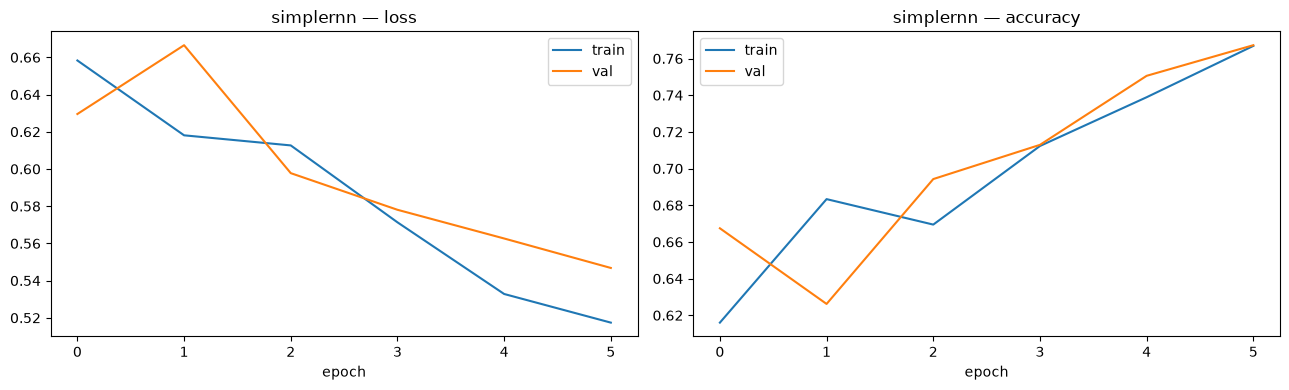

In [8]:
def build_simplernn():
    model = keras.Sequential([
        Input(shape=(SEQUENCE_LENGTH,)),
        Embedding(VOCAB_SIZE, EMBEDDING_DIM),
        SimpleRNN(32),
        Dense(1, activation="sigmoid"),
    ], name="simplernn")
    model.compile(loss=keras.losses.BinaryCrossentropy(),
                  optimizer=keras.optimizers.Adam(1e-4),
                  metrics=["accuracy"])
    return model

rnn_model = build_simplernn()
rnn_history = train_model(rnn_model, "simplernn")

### 8b. Stacked LSTM

Note `return_sequences=True` on the first LSTM: it must emit an output for **every** time step so the second
LSTM receives a sequence rather than a single vector.


=== Training: stacked_lstm ===


Model: "stacked_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 250, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 250, 64)        │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 687,617 (2.62 MB)

 Trainable params: 687,617 (2.62 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/6
223/223 ━━━━━━━━━━━━━━━━━━━━ 39s 165ms/step - accuracy: 0.6224 - loss: 0.6601 - val_accuracy: 0.6579 - val_loss: 0.6264
Epoch 2/6
223/223 ━━━━━━━━━━━━━━━━━━━━ 40s 161ms/step - accuracy: 0.7409 - loss: 0.5663 - val_accuracy: 0.7663 - val_loss: 0.5375
Epoch 3/6
223/223 ━━━━━━━━━━━━━━━━━━━━ 37s 165ms/step - accuracy: 0.7783 - loss: 0.5175 - val_accuracy: 0.7692 - val_loss: 0.5033
Epoch 4/6
223/223 ━━━━━━━━━━━━━━━━━━━━ 45s 183ms/step - accuracy: 0.7417 - loss: 0.5230 - val_accuracy: 0.7529 - val_loss: 0.5095
Epoch 5/6
223/223 ━━━━━━━━━━━━━━━━━━━━ 39s 173ms/step - accuracy: 0.8051 - loss: 0.4694 - val_accuracy: 0.8072 - val_loss: 0.4645
Epoch 6/6
223/223 ━━━━━━━━━━━━━━━━━━━━ 42s 189ms/step - accuracy: 0.7672 - loss: 0.4951 - val_accuracy: 0.7372 - val_loss: 0.5079


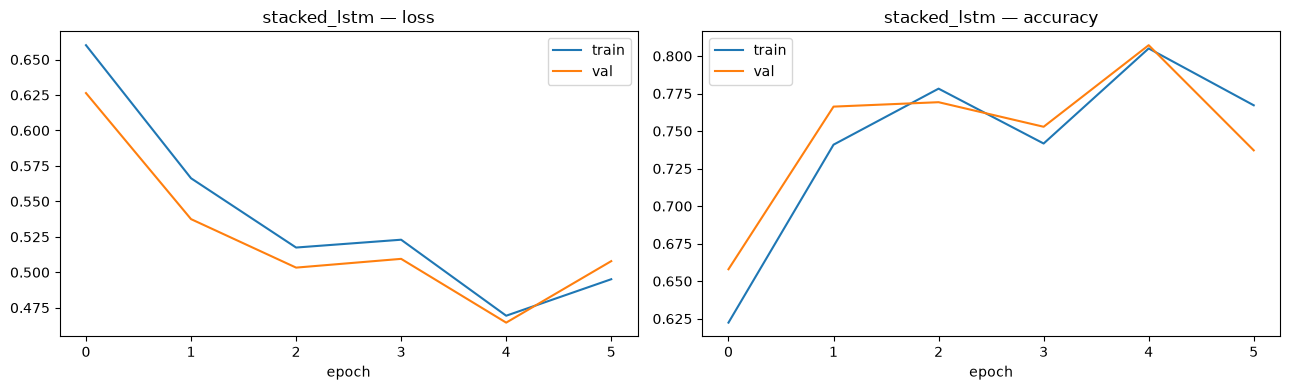

In [9]:
def build_stacked_lstm():
    model = keras.Sequential([
        Input(shape=(SEQUENCE_LENGTH,)),
        Embedding(VOCAB_SIZE, EMBEDDING_DIM),
        LSTM(64, return_sequences=True),
        LSTM(32),
        Dense(64, activation="relu"),
        Dropout(0.5),
        Dense(1, activation="sigmoid"),
    ], name="stacked_lstm")
    model.compile(loss=keras.losses.BinaryCrossentropy(),
                  optimizer=keras.optimizers.Adam(1e-4),
                  metrics=["accuracy"])
    return model

lstm_model = build_stacked_lstm()
lstm_history = train_model(lstm_model, "stacked_lstm")

### 8c. Bidirectional LSTM


=== Training: bidirectional_lstm ===


Model: "bidirectional_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 250, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 250, 128)       │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 751,489 (2.87 MB)

 Trainable params: 751,489 (2.87 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/6
223/223 ━━━━━━━━━━━━━━━━━━━━ 80s 340ms/step - accuracy: 0.7153 - loss: 0.5729 - val_accuracy: 0.8936 - val_loss: 0.2737
Epoch 2/6
223/223 ━━━━━━━━━━━━━━━━━━━━ 68s 304ms/step - accuracy: 0.9282 - loss: 0.2025 - val_accuracy: 0.9430 - val_loss: 0.1551
Epoch 3/6
223/223 ━━━━━━━━━━━━━━━━━━━━ 75s 338ms/step - accuracy: 0.9657 - loss: 0.1080 - val_accuracy: 0.9529 - val_loss: 0.1318
Epoch 4/6
223/223 ━━━━━━━━━━━━━━━━━━━━ 86s 386ms/step - accuracy: 0.9813 - loss: 0.0654 - val_accuracy: 0.9414 - val_loss: 0.1702
Epoch 5/6
223/223 ━━━━━━━━━━━━━━━━━━━━ 91s 410ms/step - accuracy: 0.9883 - loss: 0.0412 - val_accuracy: 0.9493 - val_loss: 0.1791


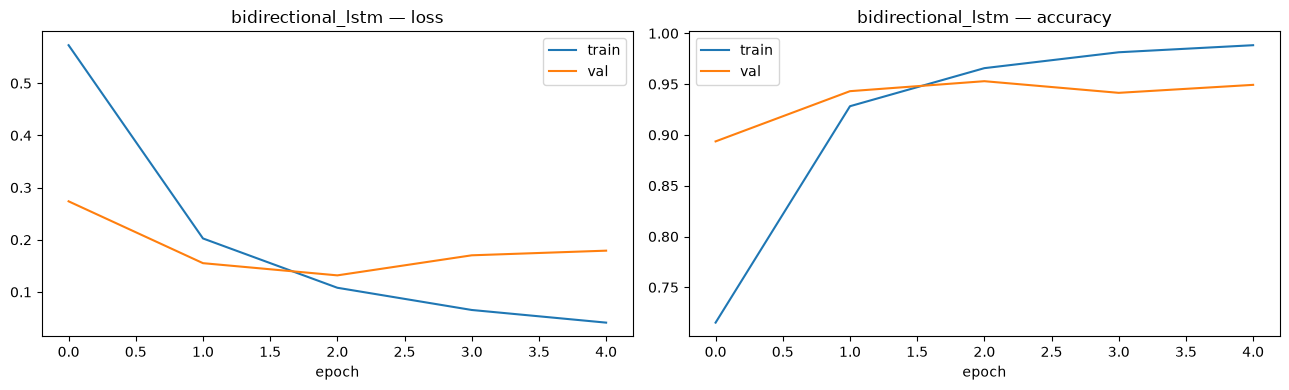

In [10]:
def build_bilstm():
    model = keras.Sequential([
        Input(shape=(SEQUENCE_LENGTH,)),
        Embedding(VOCAB_SIZE, EMBEDDING_DIM),
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(32)),
        Dense(64, activation="relu"),
        Dropout(0.5),
        Dense(1, activation="sigmoid"),
    ], name="bidirectional_lstm")
    model.compile(loss=keras.losses.BinaryCrossentropy(),
                  optimizer=keras.optimizers.Adam(1e-4),
                  metrics=["accuracy"])
    return model

bilstm_model = build_bilstm()
bilstm_history = train_model(bilstm_model, "bidirectional_lstm")

## 9. Evaluation on the held-out test set

We now score all three models on the **test** split using the metrics our business framing called for:
accuracy, precision, recall, F1, and ROC-AUC. We vectorize the test text once, then evaluate each model.

In [11]:
# Vectorize the held-out test text a single time (returns shape (N, SEQUENCE_LENGTH))
X_test_int = vectorize_layer(tf.constant(X_test))

trained = {
    "SimpleRNN":          rnn_model,
    "Stacked LSTM":       lstm_model,
    "Bidirectional LSTM": bilstm_model,
}

def evaluate_model(model):
    probs = model.predict(X_test_int, verbose=0).ravel()
    preds = (probs >= 0.5).astype(int)
    return {
        "accuracy":  accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall":    recall_score(y_test, preds, zero_division=0),
        "f1":        f1_score(y_test, preds, zero_division=0),
        "roc_auc":   roc_auc_score(y_test, probs) if len(np.unique(y_test)) > 1 else float("nan"),
    }, probs, preds

results, probs_by_model, preds_by_model = {}, {}, {}
for name, model in trained.items():
    metrics, probs, preds = evaluate_model(model)
    results[name] = metrics
    probs_by_model[name] = probs
    preds_by_model[name] = preds

results_df = pd.DataFrame(results).T[["accuracy", "precision", "recall", "f1", "roc_auc"]].round(4)
results_df = results_df.sort_values("f1", ascending=False)
print("Test-set performance (positive class = fake):")
results_df

Test-set performance (positive class = fake):


,accuracy,precision,recall,f1,roc_auc
Bidirectional LSTM,0.9525,0.9580,0.9446,0.9512,0.9894
SimpleRNN,0.7928,0.8273,0.7295,0.7753,0.8162
Stacked LSTM,0.8020,0.9077,0.6633,0.7665,0.8732


### 9a. Confusion matrices and ROC curves

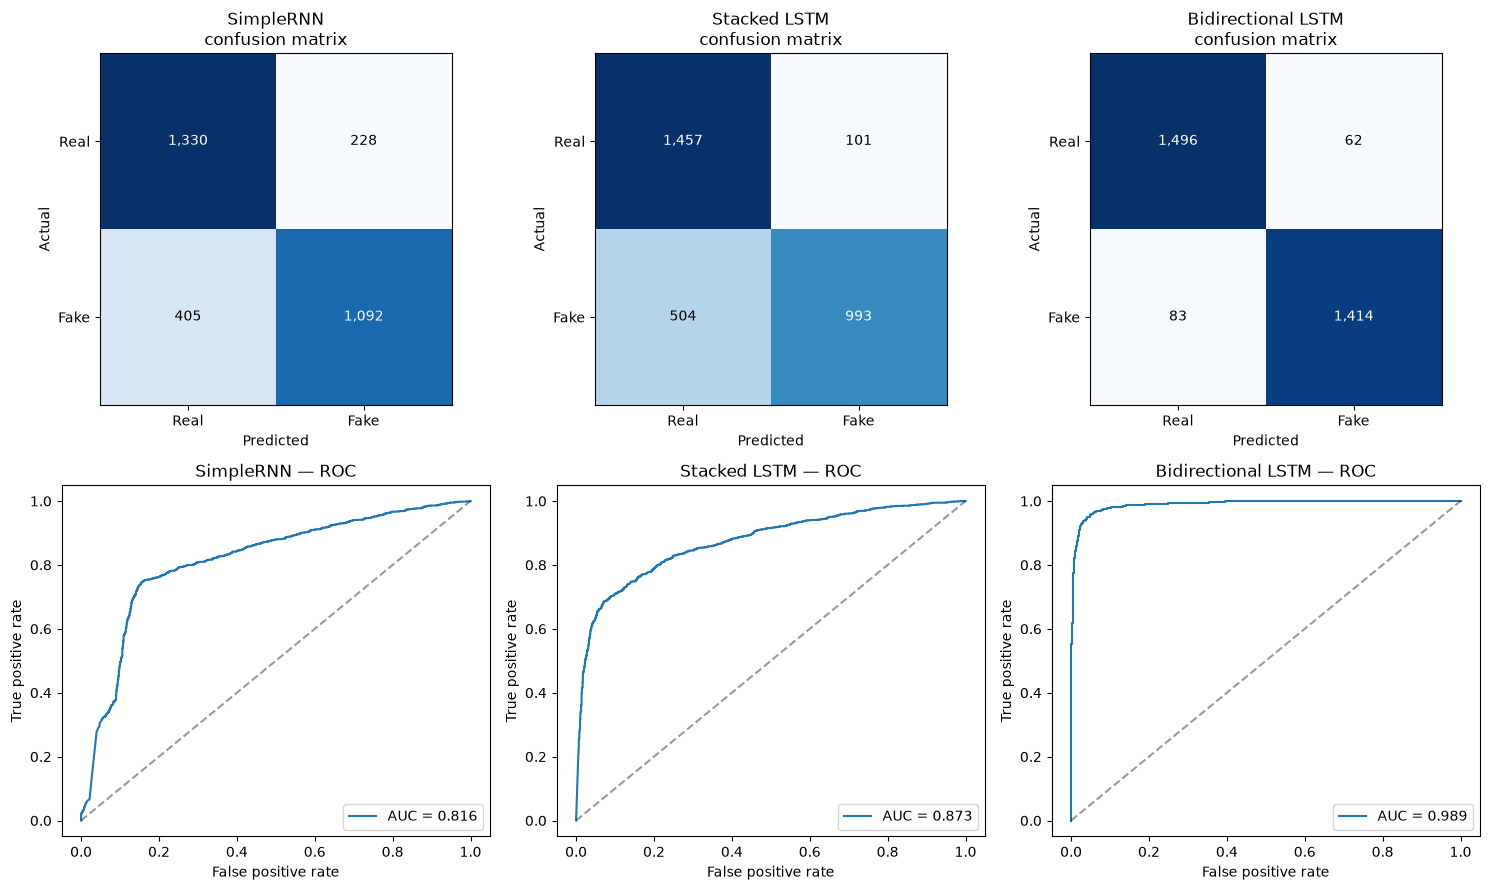

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for j, name in enumerate(trained):
    # Confusion matrix (top row)
    cm = confusion_matrix(y_test, preds_by_model[name])
    ax = axes[0, j]
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(f"{name}\nconfusion matrix")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Real", "Fake"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Real", "Fake"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    for r in range(2):
        for c in range(2):
            ax.text(c, r, f"{cm[r, c]:,}", ha="center", va="center",
                    color="white" if cm[r, c] > cm.max() / 2 else "black")

    # ROC curve (bottom row)
    ax = axes[1, j]
    if len(np.unique(y_test)) > 1:
        fpr, tpr, _ = roc_curve(y_test, probs_by_model[name])
        ax.plot(fpr, tpr, label=f"AUC = {results[name]['roc_auc']:.3f}")
        ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
        ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
        ax.set_title(f"{name} — ROC"); ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "evaluation.png"), dpi=120, bbox_inches="tight")
plt.show()

## 10. Error analysis

Looking at what the best model gets *wrong* is more informative than the headline accuracy. We separate the
two error types we costed in Section 1: **false negatives** (fake slipped through) and **false positives**
(real wrongly flagged).

In [13]:
best_name = results_df.index[0]
best_probs = probs_by_model[best_name]
best_preds = preds_by_model[best_name]
print(f"Best model by F1: {best_name}\n")

def show_errors(kind, n=3):
    if kind == "false_negative":   # actual fake (1), predicted real (0)
        mask = (y_test == 1) & (best_preds == 0)
        header = "FALSE NEGATIVES — fake articles the model missed"
    else:                          # actual real (0), predicted fake (1)
        mask = (y_test == 0) & (best_preds == 1)
        header = "FALSE POSITIVES — real articles wrongly flagged"
    idx = np.where(mask)[0]
    print("=" * 80); print(header, f"({len(idx)} total)"); print("=" * 80)
    for i in idx[:n]:
        print(f"  p(fake) = {best_probs[i]:.2f}  |  {str(X_test[i])[:140]}")
    if len(idx) == 0:
        print("  (none in the test set)")
    print()

show_errors("false_negative")
show_errors("false_positive")

print("Full classification report (best model):")
print(classification_report(y_test, best_preds, target_names=["Real", "Fake"], zero_division=0))

Best model by F1: Bidirectional LSTM

FALSE NEGATIVES — fake articles the model missed (83 total)
  p(fake) = 0.22  |  Report Copyright Violation World's Oldest Person Had Smoked For 76 Years actually, i think i remember a few of these people over the years w
  p(fake) = 0.06  |  Bono unveils album about being a woman 03-11-16 BONO has released an album about his struggles as a woman. After receiving a Women of the Ye
  p(fake) = 0.03  |  / south africa 
Issues surrounding a minimum wage bill, education and services are being utilized in attempts to overthrow the African Natio

FALSE POSITIVES — real articles wrongly flagged (62 total)
  p(fake) = 0.99  |  Dan Goodin of Ars Technica writes that the   report on Russian hacking in 2016 “provides almost no new evidence to support the Obama Adminis
  p(fake) = 0.58  |  The treatment of veterans in Veterans Affairs (VA) hospitals is an inexplicable scandal. Now try to focus on this: the federal government, i
  p(fake) = 0.85  |  HOW AMERICA

## 11. Export the model for the MVP frontend

This is the bridge to the **frontend (Streamlit `app/app.py`)**. We wrap the best trained model together
with the fitted `vectorize_layer` into a single end-to-end model that accepts **raw text strings** and
returns a fake-probability. The frontend then just loads this one file — no preprocessing code duplicated.

In [14]:
best_model = trained[best_name]

# End-to-end: raw string -> vectorize -> trained model -> p(fake)
export_model = keras.Sequential([vectorize_layer, best_model], name="fake_news_end_to_end")

# Build + sanity-check on two obvious examples.
# Note: pass a tf.string tensor (tf.constant), NOT a raw numpy string array,
# because the first layer (TextVectorization) expects string tensors.
examples = [
    "BREAKING you WONT believe this SHOCKING secret they are HIDING from you share now",
    "according to reuters officials confirmed the quarterly report was consistent with estimates",
]
preview = export_model.predict(tf.constant(examples), verbose=0).ravel()
for text, p in zip(examples, preview):
    print(f"p(fake) = {p:.3f}  <-  {text[:70]}...")

export_path = os.path.join(MODELS_DIR, "fake_news_model.keras")
export_model.save(export_path)
print(f"\nSaved end-to-end model -> {export_path}")
print(f"(best architecture: {best_name})")

p(fake) = 0.997  <-  BREAKING you WONT believe this SHOCKING secret they are HIDING from yo...
p(fake) = 0.993  <-  according to reuters officials confirmed the quarterly report was cons...

Saved end-to-end model -> ../models\fake_news_model.keras
(best architecture: Bidirectional LSTM)


### 11a. Reusable prediction helper

The exact function the frontend uses. It returns a verdict, a confidence, and the raw probability.

In [15]:
def predict_news(text, threshold=0.5):
    p = float(export_model.predict(tf.constant([text]), verbose=0).ravel()[0])
    verdict = "FAKE" if p >= threshold else "REAL"
    confidence = p if p >= threshold else 1 - p
    return {"verdict": verdict, "confidence": round(confidence, 3), "p_fake": round(p, 3)}

for t in [
    "Power outages hit France as record heatwave set to peak.",
    "SHOCKING truth EXPOSED the government is HIDING what really happened you wont believe it",
]:
    print(predict_news(t), "\n  <-", t[:70])

{'verdict': 'FAKE', 'confidence': 0.994, 'p_fake': 0.994} 
  <- Power outages hit France as record heatwave set to peak.
{'verdict': 'FAKE', 'confidence': 0.996, 'p_fake': 0.996} 
  <- SHOCKING truth EXPOSED the government is HIDING what really happened y


## 12. Summary

**What this notebook delivers**
- A leakage-free RNN/LSTM pipeline for fake-news classification.
- Three compared architectures with evaluation on accuracy, precision, recall, F1, and ROC-AUC.
- An exported end-to-end model (`models/fake_news_model.keras`) that powers the Streamlit MVP.